<a href="https://colab.research.google.com/github/lakshyapathak69420/LLM-FInetunning-on-NCERT-Maths-class-11th-and-12th/blob/master/Qwen_finetuning_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from huggingface_hub import notebook_login
notebook_login()


In [ ]:
!pip install triton

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import json
with open("math_qa_dataset.json", "r") as f:
    data = json.load(f)

questions = []
answers = []
for d in data["example"]:
    q = d["question"]
    a = d["answer"]
    questions.append(q)
    answers.append(a)
df = pd.DataFrame({"questions":questions, "answers" : answers})

In [ ]:
df.head()

,questions,answers
0,"Find the 17th term of the AP: 5, 10, 15, ...",a_n = a + (n-1)d = 5 + 16×5 = 85
1,Find the area of circle x² + y² = r² using int...,Area = 4∫₀^r √(r² - x²) dx = πr²
2,"Find the mean of: 45, 41, 22, 13, 39.",Mean = (45 + 41 + 22 + 13 + 39)/5 = 160/5 = 32.00
3,Show that f: R → R defined by f(x) = x³ is bij...,f is one-one: f(x₁) = f(x₂) ⟹ x₁³ = x₂³ ⟹ x₁ =...
4,"Find P(5, 5).","P(5, 5) = 5!/(5-5)! = 120"


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
traindf , testdf = train_test_split(df, train_size=.85, random_state=42)

In [ ]:
len(traindf)
traindf.head()

,questions,answers
8701,"If n(A) = 6, n(B) = 5, and n(A ∩ B) = 3, find ...",n(A ∪ B) = n(A) + n(B) - n(A ∩ B) = 6 + 5 - 3 = 8
3429,Find the derivative of sin(5x).,d/dx[sin(5x)] = 5cos(5x)
8870,Two coins are tossed. Find the probability of ...,"P(exactly 1 heads) = C(2,1)/4 = 2/4 = 1/2"
6962,A die is thrown. Find the probability of getti...,P(X > 2) = 4/6 = 2/3
2088,"If a = 1i + 2j and b = 1i + 3j, find a + b.",a + b = (2)i + (5)j


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [ ]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch

In [ ]:
device = "cuda" if torch.cuda.is_available() else 'cpu'

In [ ]:
model = model.to(device)

In [ ]:
prompt = "Give me a short introduction to large language model."
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
def generate_response(message):
  text = tokenizer.apply_chat_template(
      messages,
      tokenize=False,
      add_generation_prompt=True
  )
  model_inputs = tokenizer(text, return_tensors="pt").to(device)
  for key in model_inputs:
    model_inputs[key] = model_inputs[key].to(device)
  generated_ids = model.generate(
      **model_inputs,
      max_new_tokens=512
  )
  generated_ids = [
      output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
  ]

  response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

  return response

In [ ]:
answer = generate_response(messages)

In [ ]:
answer

"Sure! A large language model is a type of artificial intelligence (AI) system that can generate human-like text based on the input it receives. These models are trained using vast amounts of data and natural language processing techniques, allowing them to understand and produce coherent responses to questions, answers, and prompts in various domains such as science, technology, literature, and more.\n\nLarge language models have been used in many fields including:\n\n1. Natural Language Processing (NLP): They have been widely used in NLP tasks like sentiment analysis, question answering, and machine translation.\n2. Chatbots: Large language models are increasingly being employed in chatbot applications for customer service and support.\n3. Sentiment Analysis: Models can be trained to classify text into positive, negative, or neutral sentiments.\n4. Machine Translation: Some models have been developed to translate between multiple languages with high accuracy.\n5. Question Answering: 

In [ ]:
system_content = "You are a math expert who provides detailed, step-by-step solutions for NCERT problems"
def templatise_test(df:pd.DataFrame)->pd.DataFrame:
    data = []
    for i in range(len(df)):
        question = df["questions"].iloc[i]
        answer = df["answers"].iloc[i]
        data_templatised_ = [{"role": "system", "content":system_content}, {"role":"user", "content":question}, {"role":"assistant", "content": answer}]
        data.append(data_templatised_)
    return pd.DataFrame({"data": data})

In [ ]:
traindf = templatise_test(traindf)

In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
def project_template(df):
  tdata = []
  for i in range(len(df)):
        data = df["data"].iloc[i]
        data_templatised_ = tokenizer.apply_chat_template(data, tokenize=False)
        tdata.append(data_templatised_)
  return pd.DataFrame({"data": tdata})

In [ ]:
train_df = project_template(traindf)

In [ ]:
train_df.head()
train_df = list(train_df["data"])

In [ ]:
train_df[0]

'<|im_start|>system\nYou are a math expert who provides detailed, step-by-step solutions for NCERT problems<|im_end|>\n<|im_start|>user\nIf n(A) = 6, n(B) = 5, and n(A ∩ B) = 3, find n(A ∪ B).<|im_end|>\n<|im_start|>assistant\nn(A ∪ B) = n(A) + n(B) - n(A ∩ B) = 6 + 5 - 3 = 8<|im_end|>\n'

In [ ]:
tokenised_training_data = []
for i in range(len(train_df)):
  tokenised_training_data.append(tokenizer(train_df[i], return_tensors= "pt"))

In [ ]:
len(tokenised_training_data)

8500

In [ ]:
tokenised_training_data[0]

{'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,   6888,   6203,    879,
           5707,  11682,     11,   3019,  14319,  29208,   9904,    369,  20059,
           3399,   5322, 151645,    198, 151644,    872,    198,   2679,    308,
           4346,      8,    284,    220,     21,     11,    308,   5349,      8,
            284,    220,     20,     11,    323,    308,   4346,  11995,    102,
            425,      8,    284,    220,     18,     11,   1477,    308,   4346,
          11995,    103,    425,    568, 151645,    198, 151644,  77091,    198,
             77,   4346,  11995,    103,    425,      8,    284,    308,   4346,
              8,    488,    308,   5349,      8,    481,    308,   4346,  11995,
            102,    425,      8,    284,    220,     21,    488,    220,     20,
            481,    220,     18,    284,    220,     23, 151645,    198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
 

In [ ]:
response_template = "<|im_start|>assistant\n"
assistant_token = tokenizer.encode("assistant")[0]

In [ ]:
labels = []
for i in range(len( tokenised_training_data)):
  idx_till = list(tokenised_training_data[i]["input_ids"][0]).index(assistant_token)
  lbl = [(-100) for _ in range(idx_till+1)]
  for j in range(idx_till+1, len(tokenised_training_data[i]["input_ids"][0])):
    lbl.append(tokenised_training_data[i]["input_ids"][0][j])
  labels.append(lbl)

In [ ]:
for i in range(len(labels)):
  labels[i] = torch.tensor(labels[i])

In [ ]:
for i in range(len(labels)):
  labels[i] = labels[i].reshape(1 , len(labels[i]))

In [ ]:
labels[0]

tensor([[  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,    198,
             77,   4346,  11995,    103,    425,      8,    284,    308,   4346,
              8,    488,    308,   5349,      8,    481,    308,   4346,  11995,
            102,    425,      8,    284,    220,     21,    488,    220,     20,
            481,    220,     18,    284,    220,     23, 151645,    198]])

In [ ]:
for i in range(len(tokenised_training_data)):
  tokenised_training_data[i]["labels"] = labels[i]

In [ ]:
from datasets import Dataset

In [ ]:
for i in range(len(tokenised_training_data)):
  tokenised_training_data[i]["labels"] = tokenised_training_data[i]["labels"][0]
  tokenised_training_data[i]["input_ids"] = tokenised_training_data[i]["input_ids"][0]
  tokenised_training_data[i]["attention_mask"] = tokenised_training_data[i]["attention_mask"][0]

In [ ]:
dataset = Dataset.from_list(tokenised_training_data)

In [ ]:
max_size = -1
for i in range(len(labels)):
  max_size = max(len(labels[i][0]), max_size)


In [ ]:
max_size

126

In [ ]:
# max_size = 2*max_size

In [ ]:
from torch.utils.data import DataLoader
from transformers import DataCollatorForSeq2Seq

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,padding="max_length", max_length = max_size
)

In [ ]:
train_dataloader = DataLoader(
    dataset,
    shuffle=True,
    batch_size=8, collate_fn=data_collator
)

In [ ]:
from peft import LoraConfig, LoraModel, get_peft_model

In [ ]:
lora_config = LoraConfig(
    r = 16, lora_alpha = 32,
    target_modules = ["q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout = 0.1,
    task_type="CAUSAL_LM"
)

In [ ]:
lora_model = get_peft_model(model, lora_config, "HS_math_model")


In [ ]:
lora_model = lora_model.to(device)

In [ ]:
params = [p for p in lora_model.parameters() if p.requires_grad]


In [ ]:
import torch.optim
optimiser = torch.optim.AdamW(params = params, lr=3e-4)

In [ ]:
epochs = 3
training_losses = []

In [ ]:
!pip install tqdm

In [ ]:
from tqdm import tqdm

In [ ]:
len(tokenised_training_data)

8500

In [ ]:
lora_model.train()
n_iter = 0
for i in range(epochs):
  total_loss = 0
  for batch in tqdm(train_dataloader):
      n_iter += 1
      item = {name : related_tensor.to(device) for name , related_tensor in batch.items()}

      outputs = lora_model(**item)
      loss = outputs.loss
      loss.backward()
      optimiser.step()
      optimiser.zero_grad()
      total_loss += loss.item()
      training_losses.append(loss.item())
  avg_loss = total_loss / len(train_dataloader)
  print(f"\n avergae loss of {i+1}th epochs is {avg_loss}")

100%|██████████| 1063/1063 [21:57<00:00,  1.24s/it]



 avergae loss of 1th epochs is 0.07168667997145518


100%|██████████| 1063/1063 [22:05<00:00,  1.25s/it]



 avergae loss of 2th epochs is 0.07032389489609395


100%|██████████| 1063/1063 [22:08<00:00,  1.25s/it]


 avergae loss of 3th epochs is 0.04397372029404853


In [ ]:
lora_model.save_pretrained('lora_adapters')

In [ ]:
from  math import log10
log_loss = [log10(x) for x in training_losses]
number_iter = [i+1 for i in range(n_iter)]

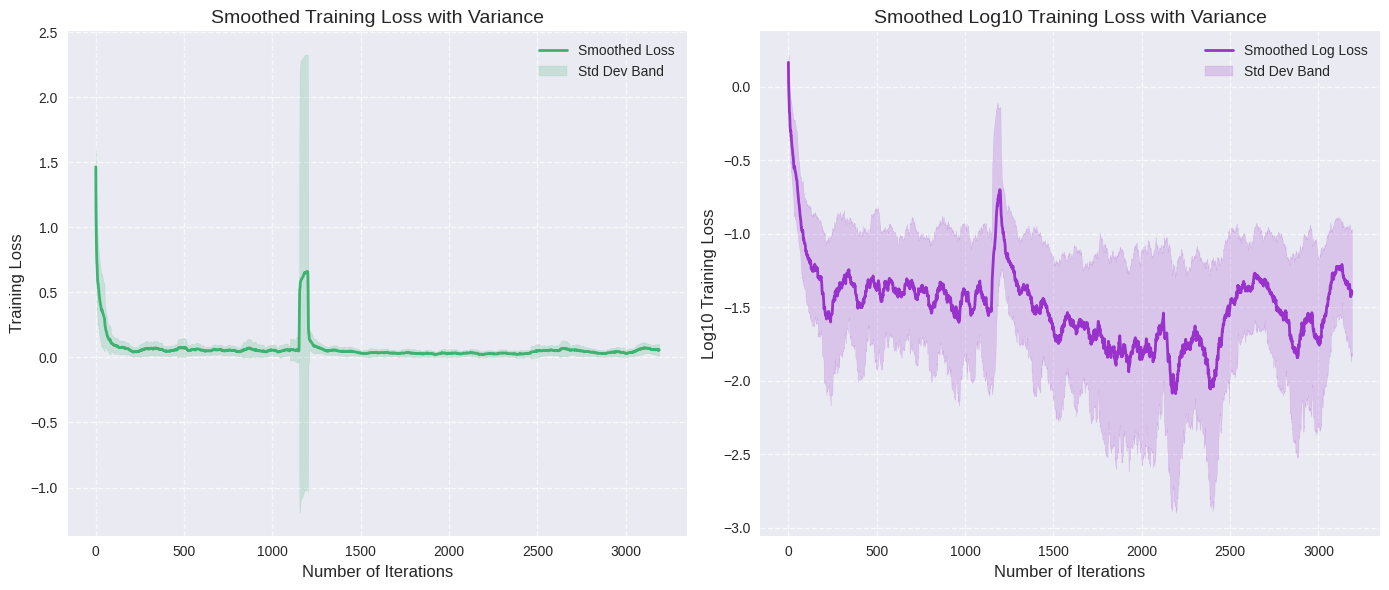

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Use a seaborn style for better aesthetics
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(14, 6)) # Slightly increase figure size for better clarity

# Convert lists to pandas Series for rolling calculations
training_losses_series = pd.Series(training_losses)
log_loss_series = pd.Series(log_loss)

# Define a window for rolling mean and std (e.g., 50 iterations)
window_size = 50

# Calculate rolling mean and standard deviation for training_losses
smoothed_training_losses = training_losses_series.rolling(window=window_size, min_periods=1).mean()
std_training_losses = training_losses_series.rolling(window=window_size, min_periods=1).std()

# Calculate rolling mean and standard deviation for log_loss
smoothed_log_loss = log_loss_series.rolling(window=window_size, min_periods=1).mean()
std_log_loss = log_loss_series.rolling(window=window_size, min_periods=1).std()

# Plot for Training Loss
plt.subplot(1, 2, 1)
plt.plot(number_iter, smoothed_training_losses, color='mediumseagreen', linewidth=2, label='Smoothed Loss')
plt.fill_between(
    number_iter,
    smoothed_training_losses - std_training_losses,
    smoothed_training_losses + std_training_losses,
    color='mediumseagreen', alpha=0.2, label='Std Dev Band'
)
plt.xlabel('Number of Iterations', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Smoothed Training Loss with Variance', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.legend()

# Plot for Log10 Training Loss
plt.subplot(1, 2, 2)
plt.plot(number_iter, smoothed_log_loss, color='darkorchid', linewidth=2, label='Smoothed Log Loss')
plt.fill_between(
    number_iter,
    smoothed_log_loss - std_log_loss,
    smoothed_log_loss + std_log_loss,
    color='darkorchid', alpha=0.2, label='Std Dev Band'
)
plt.xlabel('Number of Iterations', fontsize=12)
plt.ylabel('Log10 Training Loss', fontsize=12)
plt.title('Smoothed Log10 Training Loss with Variance', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
!zip lora_adapters.zip lora_adapters

  adding: lora_adapters/ (stored 0%)


In [ ]:
testdf = templatise_test(testdf)
test_df = project_template(testdf)
test_df = list(test_df["data"])

tokenised_testing_data = []
for i in range(len(test_df)):
  tokenised_testing_data.append(tokenizer(test_df[i], return_tensors= "pt"))


test_labels = []
for i in range(len(tokenised_testing_data)):
  idx_till = list(tokenised_testing_data[i]["input_ids"][0]).index(assistant_token)
  lbl = [(-100) for _ in range(idx_till+1)]
  for j in range(idx_till+1, len(tokenised_testing_data[i]["input_ids"][0])):
    lbl.append(tokenised_testing_data[i]["input_ids"][0][j])
  test_labels.append(lbl)

for i in range(len(test_labels)):
  test_labels[i] = torch.tensor(test_labels[i])

for i in range(len(test_labels)):
  test_labels[i] = test_labels[i].reshape(1 , len(test_labels[i]))

for i in range(len(tokenised_testing_data)):
  tokenised_testing_data[i]["labels"] = test_labels[i]

for i in range(len(tokenised_testing_data)):
  tokenised_testing_data[i]["labels"] = tokenised_testing_data[i]["labels"][0]
  tokenised_testing_data[i]["input_ids"] = tokenised_testing_data[i]["input_ids"][0]
  tokenised_testing_data[i]["attention_mask"] = tokenised_testing_data[i]["attention_mask"][0]


val_dataset = Dataset.from_list(tokenised_testing_data)

val_dataloader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=8, collate_fn=data_collator
)

In [ ]:
lora_model.eval()
validation_losses_lora_on = []

print("\n--- Validation with LoRA adapters ON ---")
with torch.no_grad():
  total_val_loss_lora_on = 0
  for batch in tqdm(val_dataloader, desc="Validating (LoRA ON)"):
      item = {name : related_tensor.to(device) for name , related_tensor in batch.items()}
      outputs = lora_model(**item)
      loss = outputs.loss
      total_val_loss_lora_on += loss.item()
      validation_losses_lora_on.append(loss.item())

  avg_val_loss_lora_on = total_val_loss_lora_on / len(val_dataloader)
  print(f"Average Validation Loss (LoRA ON): {avg_val_loss_lora_on:.4f}")


# Merge LoRA adapters into the base model for evaluation with adapters off

validation_losses_lora_off = []
print("\n--- Validation with LoRA adapters OFF (merged model) ---")
with lora_model.disable_adapter():
  with torch.no_grad():
    total_val_loss_lora_off = 0
    for batch in tqdm(val_dataloader, desc="Validating (LoRA OFF)"):
        item = {name : related_tensor.to(device) for name , related_tensor in batch.items()}
        outputs = model(**item)
        loss = outputs.loss
        total_val_loss_lora_off += loss.item()
        validation_losses_lora_off.append(loss.item())

  avg_val_loss_lora_off = total_val_loss_lora_off / len(val_dataloader)
  print(f"Average Validation Loss (LoRA OFF): {avg_val_loss_lora_off:.4f}")


--- Validation with LoRA adapters ON ---


Validating (LoRA ON): 100%|██████████| 188/188 [01:50<00:00,  1.70it/s]


Average Validation Loss (LoRA ON): 0.0596

--- Validation with LoRA adapters OFF (merged model) ---


Validating (LoRA OFF): 100%|██████████| 188/188 [01:39<00:00,  1.89it/s]

Average Validation Loss (LoRA OFF): 1.3255


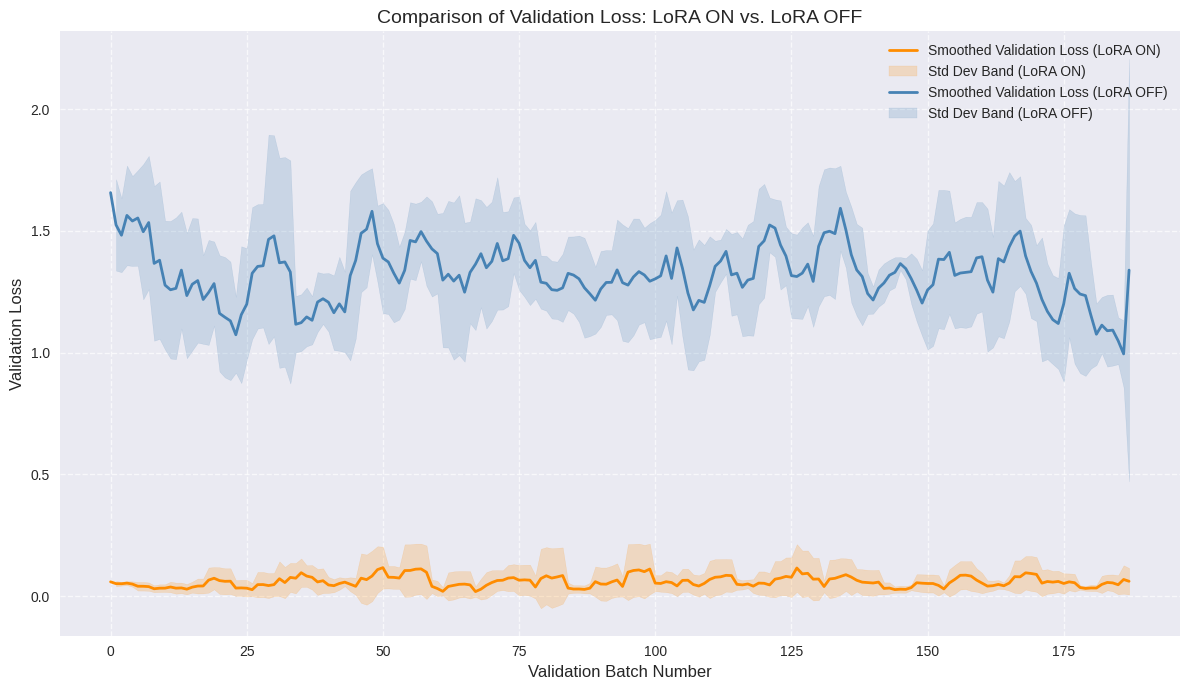

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

plt.figure(figsize=(12, 7))

validation_losses_lora_on_series = pd.Series(validation_losses_lora_on)
validation_losses_lora_off_series = pd.Series(validation_losses_lora_off)

# Define a window for rolling mean and std
window_size = 5 # You can adjust this based on the length of your validation losses

# Calculate rolling mean and standard deviation for LoRA ON
smoothed_val_losses_on = validation_losses_lora_on_series.rolling(window=window_size, min_periods=1).mean()
std_val_losses_on = validation_losses_lora_on_series.rolling(window=window_size, min_periods=1).std()

# Calculate rolling mean and standard deviation for LoRA OFF
smoothed_val_losses_off = validation_losses_lora_off_series.rolling(window=window_size, min_periods=1).mean()
std_val_losses_off = validation_losses_lora_off_series.rolling(window=window_size, min_periods=1).std()

# Number of batches for validation
num_batches_val_on = range(len(validation_losses_lora_on))
num_batches_val_off = range(len(validation_losses_lora_off))

# Plot Validation Loss with LoRA ON
plt.plot(num_batches_val_on, smoothed_val_losses_on, color='darkorange', linewidth=2, label='Smoothed Validation Loss (LoRA ON)')
plt.fill_between(
    num_batches_val_on,
    smoothed_val_losses_on - std_val_losses_on,
    smoothed_val_losses_on + std_val_losses_on,
    color='darkorange', alpha=0.2, label='Std Dev Band (LoRA ON)'
)

# Plot Validation Loss with LoRA OFF
plt.plot(num_batches_val_off, smoothed_val_losses_off, color='steelblue', linewidth=2, label='Smoothed Validation Loss (LoRA OFF)')
plt.fill_between(
    num_batches_val_off,
    smoothed_val_losses_off - std_val_losses_off,
    smoothed_val_losses_off + std_val_losses_off,
    color='steelblue', alpha=0.2, label='Std Dev Band (LoRA OFF)'
)

plt.xlabel('Validation Batch Number', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Comparison of Validation Loss: LoRA ON vs. LoRA OFF', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
!pip install rouge_score
!pip install sacrebleu

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e2e4abfb05dc9735eb5f2e1b337bc76c6779dca35465a44eea2c01f3d446b10d
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.8 MB/s eta 0:00:00


In [ ]:
import torch
from tqdm import tqdm
from rouge_score import rouge_scorer
from sacrebleu.metrics import BLEU
from sklearn.model_selection import train_test_split


def generate_prediction(question, model, tokenizer, device):
    messages = [
        {"role": "system", "content": "You are a math expert who provides detailed, step-by-step solutions for NCERT problems"},
        {"role": "user", "content": question}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer(text, return_tensors="pt").to(device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )
    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

_, testdf_original = train_test_split(df, train_size=.85, random_state=42)

sample_test_df = testdf_original.sample(min(50, len(testdf_original)), random_state=42) # Evaluate on 50 samples or less if testdf is smaller

references = sample_test_df["answers"].tolist()
predictions = []

print("Generating predictions...")
for question in tqdm(sample_test_df["questions"], desc="Generating Predictions"):
    pred = generate_prediction(question, model, tokenizer, device)
    predictions.append(pred)

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougel_scores = []

print("Calculating ROUGE scores...")
for ref, pred in tqdm(zip(references, predictions), total=len(references), desc="Calculating ROUGE"):
    scores = scorer.score(ref, pred)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougel_scores.append(scores['rougeL'].fmeasure)

# Calculate average ROUGE scores
avg_rouge1 = sum(rouge1_scores) / len(rouge1_scores)
avg_rouge2 = sum(rouge2_scores) / len(rouge2_scores)
avg_rougel = sum(rougel_scores) / len(rougel_scores)

print(f"Average ROUGE-1 F-measure: {avg_rouge1:.4f}")
print(f"Average ROUGE-2 F-measure: {avg_rouge2:.4f}")
print(f"Average ROUGE-L F-measure: {avg_rougel:.4f}")

# Initialize BLEU scorer
bleu = BLEU()

bleu_scores = []

print("Calculating BLEU scores...")
for ref, pred in tqdm(zip(references, predictions), total=len(references), desc="Calculating BLEU"):
    # sacrebleu expects references as a list of lists of strings
    # e.g., [['reference 1'], ['reference 2']]
    score = bleu.sentence_score(pred, [ref]).score
    bleu_scores.append(score)

# Calculate average BLEU score
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"Average BLEU score: {avg_bleu:.4f}")

Generating predictions...


Generating Predictions: 100%|██████████| 50/50 [01:55<00:00,  2.30s/it]


Calculating ROUGE scores...


Calculating ROUGE: 100%|██████████| 50/50 [00:00<00:00, 4439.36it/s]


Average ROUGE-1 F-measure: 0.9457
Average ROUGE-2 F-measure: 0.9227
Average ROUGE-L F-measure: 0.9457
Calculating BLEU scores...


Calculating BLEU: 100%|██████████| 50/50 [00:00<00:00, 883.47it/s]

Average BLEU score: 90.4748


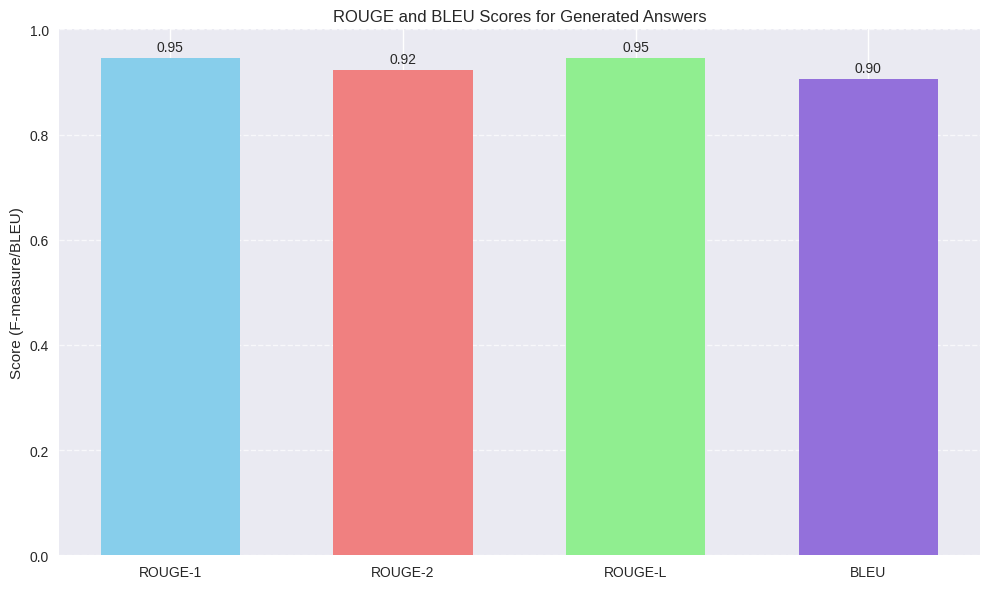

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
scores = [avg_rouge1, avg_rouge2, avg_rougel, avg_bleu / 100] # BLEU is usually 0-100, convert to 0-1 for comparison

x = np.arange(len(metrics))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 6))
rects = ax.bar(x, scores, width, color=['skyblue', 'lightcoral', 'lightgreen', 'mediumpurple'])

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score (F-measure/BLEU)')
ax.set_title('ROUGE and BLEU Scores for Generated Answers')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1) # Scores are typically between 0 and 1

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()